In [ ]:
import pandas as pd
import numpy as np
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import train_test_split
from Levenshtein import distance as levenshtein_distance
from collections import defaultdict
from collections import Counter
from itertools import combinations
from tqdm import tqdm
from difflib import SequenceMatcher
from multiprocessing import Pool
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, classification_report, confusion_matrix
)
import hashlib
import random
import math
import json
import os
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [481]:
# Загрузка данных
df = pd.read_parquet('split_label_train_V3.snappy.parquet')

1. EDA 

In [482]:
# Проверка размера датасета
print("Размер датасета:")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

Размер датасета:
Количество строк: 68036
Количество столбцов: 12


In [ ]:
#1. Проверка типов данных и непропущенных значений
print("Типы данных и количество непропущенных значений:")
display(df.info())

Типы данных и количество непропущенных значений:
<class 'pandas.DataFrame'>
RangeIndex: 68036 entries, 0 to 68035
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   created_at               68036 non-null  datetime64[ns]
 1   first_name               18479 non-null  str           
 2   last_name                1621 non-null   str           
 3   email                    68036 non-null  str           
 4   phone                    4966 non-null   str           
 5   birthday                 407 non-null    object        
 6   sex                      67984 non-null  str           
 7   non_processing_features  67795 non-null  object        
 8   realtime_features        67795 non-null  str           
 9   fs_features              67795 non-null  object        
 10  profile_id               68036 non-null  str           
 11  entity_id                68036 non-null  str           

None

In [485]:
# Подсчет пропусков в каждом столбце
print("Количество пропусков в каждом столбце:")
display(df.isnull().sum())

Количество пропусков в каждом столбце:


created_at                     0
first_name                 49557
last_name                  66415
email                          0
phone                      63070
birthday                   67629
sex                           52
non_processing_features      241
realtime_features            241
fs_features                  241
profile_id                     0
entity_id                      0
dtype: int64

In [486]:
# Анализ пропусков по entity_id
# Группируем по entity_id и считаем пропуски для ключевых полей
entity_missing = df.groupby('entity_id').agg({
    'first_name': lambda x: x.isnull().sum(),
    'last_name': lambda x: x.isnull().sum(),
    'email': lambda x: x.isnull().sum(),
    'phone': lambda x: x.isnull().sum(),
    'birthday': lambda x: x.isnull().sum(),
    'sex': lambda x: x.isnull().sum()
}).reset_index()

# Общее количество профилей в каждой entity
profile_counts = df['entity_id'].value_counts().reset_index()
profile_counts.columns = ['entity_id', 'profile_count']
entity_missing = entity_missing.merge(profile_counts, on='entity_id')

# Категории пропусков
entity_missing['all_missing'] = (
    (entity_missing['first_name'] == entity_missing['profile_count']) &
    (entity_missing['last_name'] == entity_missing['profile_count']) &
    (entity_missing['email'] == entity_missing['profile_count']) &
    (entity_missing['phone'] == entity_missing['profile_count'])
)

entity_missing['partial_missing'] = (
    ~entity_missing['all_missing'] &
    ((entity_missing['first_name'] > 0) |
     (entity_missing['last_name'] > 0) |
     (entity_missing['email'] > 0) |
     (entity_missing['phone'] > 0))
)

# Статистика
print("Статистика пропусков по entity_id:")
print(f"Всего уникальных entity: {len(entity_missing)}")
print(f"Entity полностью без данных по ключевым полям: {entity_missing['all_missing'].sum()}")
print(f"Entity с частичными пропусками: {entity_missing['partial_missing'].sum()}")

Статистика пропусков по entity_id:
Всего уникальных entity: 53369
Entity полностью без данных по ключевым полям: 0
Entity с частичными пропусками: 53153


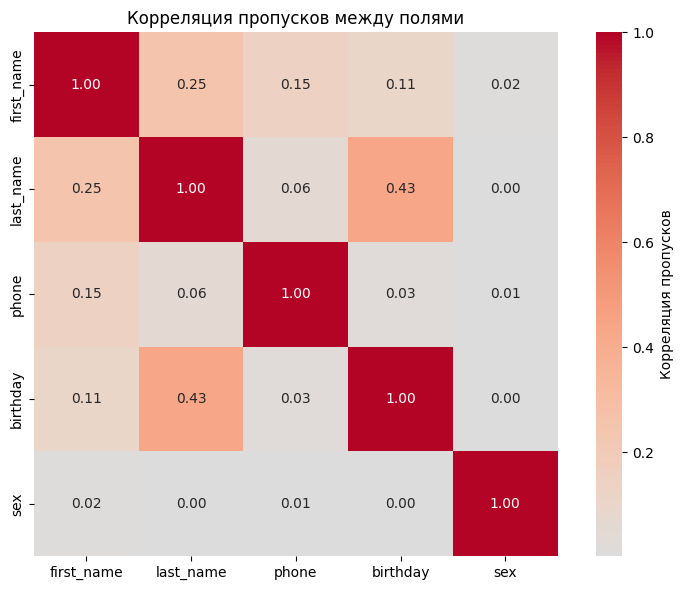

In [487]:
# Матрица корреляции пропусков
missing_correlation = df[['first_name', 'last_name', 'phone', 'birthday', 'sex']].isna().corr()

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(missing_correlation, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Корреляция пропусков'})
plt.title('Корреляция пропусков между полями')
plt.tight_layout()
plt.show()


In [488]:
# Количество дубликатов
# Выбираем столбцы без массивов
subset_cols = [
    'profile_id', 'entity_id',
    'created_at', 'first_name', 'last_name',
    'email', 'phone', 'birthday', 'sex'
]

# Ищем дубликаты только по этим столбцам
duplicates = df.duplicated(subset=subset_cols).sum()
print(f"Количество дубликатов: {duplicates}")


Количество дубликатов: 0


In [489]:
unique_profile_count = df['profile_id'].nunique()
unique_entity_count = df['entity_id'].nunique()


print(f"Количество уникальных profile_id: {unique_profile_count}")
print(f"Количество уникальных entity_id: {unique_entity_count}")

Количество уникальных profile_id: 61927
Количество уникальных entity_id: 53369


In [490]:
# Создаём комбинацию имени и фамилии
df['name_combination'] = df['first_name'] + ' ' + df['last_name']

# Группируем по entity_id и считаем уникальные комбинации имён
name_per_entity = (
    df
    .groupby('entity_id')['name_combination']
    .nunique()
    .reset_index()
)
name_per_entity.columns = ['entity_id', 'unique_name_combinations']

print("Статистика по уникальным комбинациям имён на entity_id:")
print(f"Среднее количество: {name_per_entity['unique_name_combinations'].mean():.2f}")
print(f"Медиана: {name_per_entity['unique_name_combinations'].median()}")
print(f"Максимум: {name_per_entity['unique_name_combinations'].max()}")
print(f"Минимум: {name_per_entity['unique_name_combinations'].min()}")


Статистика по уникальным комбинациям имён на entity_id:
Среднее количество: 0.03
Медиана: 0.0
Максимум: 2
Минимум: 0


In [491]:
# Паттерны написания имен
def analyze_name_patterns(df):
    name_patterns = {
        'full_name': df['first_name'].str.contains(' ', na=False).sum(),
        'initials': df['first_name'].str.match(r'^[А-ЯA-Z]\.$', na=False).sum(),
        'translit': df['first_name'].str.contains(r'[a-zA-Z]', na=False).sum(),
        'cyrillic_only': df['first_name'].str.contains(r'[а-яА-Я]', na=False).sum()
    }
    return pd.Series(name_patterns)

name_patterns = analyze_name_patterns(df)
print("Паттерны написания имён:")
print(name_patterns)


Паттерны написания имён:
full_name            0
initials             0
translit             0
cyrillic_only    18479
dtype: int64


In [492]:
# Анализ email
# Извлекаем домен из email
df['email_domain'] = df['email'].str.split('@').str[-1]

# Группируем по entity_id и домену, считаем количество
domain_per_entity = df.groupby(['entity_id', 'email_domain']).size().reset_index(name='count')


print("=== Анализ email доменов ===")
print(
    f"Всего уникальных entity_id с email: "
    f"{df[df['email'].notna()]['entity_id'].nunique()}"
)

# Профили с одинаковым доменом у одного entity_id
same_domain_entities = domain_per_entity[domain_per_entity['count'] > 1]
print(
    f"\nentity_id с несколькими профилями на одном домене: "
    f"{same_domain_entities['entity_id'].nunique()}"
)


=== Анализ email доменов ===
Всего уникальных entity_id с email: 53369

entity_id с несколькими профилями на одном домене: 5660


In [493]:
# Анализ по номеру телефона
df['country_code'] = df['phone'].str[:2] 
df['operator_code'] = df['phone'].str[2:5]  

# Группируем по entity_id, проверяем согласованность кодов
phone_consistency = df.groupby('entity_id')[['country_code', 'operator_code']].nunique()

# Считаем entity_id с разными кодами
inconsistent_country = phone_consistency[
    phone_consistency['country_code'] > 1
].index
inconsistent_operator = phone_consistency[
    phone_consistency['operator_code'] > 1
].index

print("\n=== Анализ телефонов ===")
print(f"entity_id с разными кодами страны: {len(inconsistent_country)}")
print(f"entity_id с разными кодами оператора: {len(inconsistent_operator)}")

# Частота полного совпадения анонимизированных номеров
full_phone_match = df.groupby('entity_id')['phone'].nunique().value_counts()

print(f"\nЧастота полного совпадения номеров:")
for count, freq in full_phone_match.items():
    if count == 1:
        print(f"Полное совпадение во всех профилях: {freq} entity_id")
    else:
        print(f"{count} разных номера: {freq} entity_id")



=== Анализ телефонов ===
entity_id с разными кодами страны: 0
entity_id с разными кодами оператора: 51

Частота полного совпадения номеров:
0 разных номера: 48842 entity_id
Полное совпадение во всех профилях: 4476 entity_id
2 разных номера: 51 entity_id


In [494]:
# Анализ форматов данных
def analyze_phone_formats(df):
    # Создаём копию для безопасности
    temp_df = df[['phone']].copy()
    
    # Извлекаем только цифры для анализа форматов
    temp_df['phone_digits'] = temp_df['phone'].str.replace(r'\D', '', regex=True)
    # Обработка пропусков
    temp_df['phone_digits'] = temp_df['phone_digits'].fillna('')
    
    # Определяем шаблоны в порядке приоритета
    patterns = [
        ('11_digits_7', r'^7\d{10}$'),      # 11 цифр, начинается с 7
        ('11_digits_8', r'^8\d{10}$'),      # 11 цифр, начинается с 8
        ('7_digits_local', r'^\d{7}$')     # 7 цифр — локальные номера     
    ]
    
    # Инициализируем колонку для формата
    temp_df['phone_format'] = 'other'
    
    # Применяем шаблоны в порядке приоритета (первый подходящий)
    for format_name, pattern in patterns:
        mask = temp_df['phone_digits'].str.match(pattern)
        # Обновляем только те записи, которые ещё не классифицированы
        temp_df.loc[mask & (temp_df['phone_format'] == 'other'), 'phone_format'] = format_name
    
    
    # Считаем распределение
    format_counts = temp_df['phone_format'].value_counts()
    return format_counts

# Запуск анализа
phone_formats = analyze_phone_formats(df)
print("Распределение форматов телефонов:")
print(phone_formats)


Распределение форматов телефонов:
phone_format
other          63070
11_digits_7     4966
Name: count, dtype: int64


In [495]:
# Анализ даты рождения
# Проверяем совпадение birthday у профилей одного entity_id
df['birthday'] = pd.to_datetime(df['birthday'])
birthday_consistency = df.groupby('entity_id')['birthday'].nunique()
inconsistent_birthday = birthday_consistency[birthday_consistency > 1].index

print("\n=== Анализ дат рождения ===")
print(f"entity_id с разными датами рождения: {len(inconsistent_birthday)}")

# Ищем даты 01.01 
df['birth_day_month'] = df['birthday'].dt.strftime('%d.%m')
jan_first_mask = df[df['birth_day_month'] == '01.01']

masked_entities = jan_first_mask.groupby('entity_id').size()
print(f"\nentity_id с датой рождения 01.01: {len(masked_entities)}")

# Считаем entity_id с разными датами среди маскированных
masked_with_different_dates = masked_entities[masked_entities > 1]
print(
    f"Из них с разными датами: {len(masked_with_different_dates)}"
)

# Статистика датам 01.01
masked_stats = jan_first_mask['entity_id'].value_counts().value_counts()

print("Распределение entity_id по количеству дат 01.01:")
for count, freq in masked_stats.items():
    print(f"{count}: {freq} entity_id")



=== Анализ дат рождения ===
entity_id с разными датами рождения: 0

entity_id с датой рождения 01.01: 368
Из них с разными датами: 22
Распределение entity_id по количеству дат 01.01:
1: 346 entity_id
2: 14 entity_id
3: 5 entity_id
5: 2 entity_id
7: 1 entity_id


In [ ]:
# Анализ по полу
# Проверяем согласованность пола у профилей одного entity_id
sex_consistency = df.groupby('entity_id')['sex'].nunique()
inconsistent_sex = sex_consistency[sex_consistency > 1].index

print("\n=== Анализ пола ===")
print(f"entity_id с разным полом в профилях: {len(inconsistent_sex)}")

# Детальная статистика по несогласованности
inconsistent_data = df[df['entity_id'].isin(inconsistent_sex)]
sex_distribution = inconsistent_data.groupby('entity_id')['sex'].value_counts()

# Общая статистика по полу
total_entities = df['entity_id'].nunique()
consistent_entities = total_entities - len(inconsistent_sex)
print(f"\nСогласованность пола: {consistent_entities / total_entities:.2%}")



=== Анализ пола ===
entity_id с разным полом в профилях: 2315

Примеры несогласованности пола:
entity_id 0053d4a01d567b83c8ecb9111a37e8c57b18fe4fedff15ecf25fdc1b331fa753: ['male', 'unknown']
entity_id 00931ed389e1ae904927d4a8ede34d1b742a327519fcf9dc30818318db46c40b: ['female', 'unknown']
entity_id 009d76a1c862a21d0b7e1df11221242fe25ceb13053a7e709cb56bfa4c4a4299: ['unknown', 'female']
entity_id 009e708e1f25c0c285062730472206bc57d5e3c9497762f22fc0ef3a0dbc6ea2: ['unknown', 'female']
entity_id 00d10b3149a8654b1dd2691675826b5a54e7aa95f6c0f904c45afe3c30eccdf9: ['female', 'unknown']

Согласованность пола: 95.66%


In [497]:
# Временной анализ
df['date'] = df['created_at'].dt.date
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek

# Распределение дубликатов по времени
multi_profiles = df[df['entity_id'].isin(
    df['entity_id'].value_counts()[df['entity_id'].value_counts() > 1].index
)]
day_of_week_stats = (multi_profiles.groupby('day_of_week').size()
                      .rename(index={
                          0: 'Понедельник',
                          1: 'Вторник',
                          2: 'Среда',
                          3: 'Четверг',
                          4: 'Пятница',
                          5: 'Суббота',
                          6: 'Воскресенье'
                      }))
print("\nРаспределение multi-profile по дням недели:")
print(day_of_week_stats)

hour_stats = multi_profiles.groupby('hour').size()
print("\nРаспределение multi-profile по часам суток:")
print(hour_stats)



Распределение multi-profile по дням недели:
day_of_week
Понедельник    3108
Вторник        3178
Среда          3072
Четверг        3296
Пятница        3279
Суббота        3568
Воскресенье    3440
dtype: int64

Распределение multi-profile по часам суток:
hour
0      342
1      400
2      493
3      661
4      850
5      923
6      967
7     1047
8     1002
9     1095
10    1077
11    1133
12    1162
13    1278
14    1246
15    1343
16    1518
17    1521
18    1429
19    1183
20     946
21     620
22     387
23     318
dtype: int64


In [498]:
# Количество профилей на одного человека
entity_profile_counts = (df.groupby('entity_id').size()
                         .value_counts()
                         .sort_index())
print("\nРаспределение количества профилей на одного entity:")
print(entity_profile_counts)
print(f"\nМаксимум профилей на одного человека: {df.groupby('entity_id').size().max()}")



Распределение количества профилей на одного entity:
1      45095
2       5196
3       1740
4        650
5        317
6        144
7         71
8         54
9         32
10        22
11        15
12         8
13         3
14         4
15         4
16         1
17         3
18         1
20         1
22         1
26         2
27         1
28         1
37         1
40         1
116        1
Name: count, dtype: int64

Максимум профилей на одного человека: 116


In [499]:
# Временные интервалы между профилями
def calculate_time_gaps(group):
    sorted_times = group['created_at'].sort_values()
    gaps = sorted_times.diff().dropna()
    return pd.Series({
        'min_gap_hours': gaps.min().total_seconds() / 3600 if not gaps.empty else 0,
        'max_gap_hours': gaps.max().total_seconds() / 3600 if not gaps.empty else 0,
        'mean_gap_hours': gaps.mean().total_seconds() / 3600 if not gaps.empty else 0,
        'profile_count': len(group)
    })

time_gap_stats = df.groupby('entity_id').apply(calculate_time_gaps)
print("\nСтатистика по временным интервалам между профилями:")
print(time_gap_stats.describe())



Статистика по временным интервалам между профилями:
       min_gap_hours  max_gap_hours  mean_gap_hours  profile_count
count   53369.000000   53369.000000    53369.000000   53369.000000
mean       77.881042     116.763734       94.575760       1.274822
std       366.385064     442.544797      384.158079       1.031836
min         0.000000       0.000000        0.000000       1.000000
25%         0.000000       0.000000        0.000000       1.000000
50%         0.000000       0.000000        0.000000       1.000000
75%         0.000000       0.000000        0.000000       1.000000
max      4480.027599    4496.630130     4480.027599     116.000000


Выводы: 

Объём: 68 036 строк, 12 столбцов.

Уникальных entity: 53 369 — многие entity представлены несколькими профилями.

Распределение профилей на entity:

45 095 entity имеют 1 профиль (84,5 %);

5 196 entity имеют 2 профиля (9,7 %);

остальные (5,8 %) — от 3 до 116 профилей на одного человека.

Максимум профилей на одного человека: 116 — есть крайне сложные случаи дублирования.


Качество данных и пропуски:

first_name: 72,8 % пропусков (18 479 из 68 036);

last_name: 97,6 % пропусков (1 621 из 68 036);

phone: 92,7 % пропусков (4 966 из 68 036);

birthday: 99,4 % пропусков (407 из 68 036).

Наблюдается умеренная положительная корреляция  0.43 между пропусками last_name и birthday:

когда  пропущена фамилия, чаще, чем случайно, пропущена и дата рождения - и наоборот.

Сила связи несильная, но значимая закономерность.

Пользователи либо заполняют все персональные данные, либо почти ничего не указывают.

Опора на ФИО, телефон и дату рождения для матчинга сильно ограничена.

Основные источники информации: email, sex, fs_features, realtime_features.

Требуется разработка признаков, устойчивых к пропускам.

Анализ ключевых полей

Email:

У 5 660 entity есть несколько профилей на одном домене — это сильный сигнал для матчинга.

Сохранённый домен позволяет использовать его как признак сходства.

Телефон:

Дисбаланс: только 7,3 % номеров имеют «идеальный» формат для матчинга.

Необходима нормализация.

Дата рождения:

Нет entity с разными датами рождения — признак надёжен при наличии данных.

368 entity имеют дату 01.01.

Пол:

2 315 entity имеют разный пол в профилях (4,3 % от всех entity).

Согласованность пола: 95,66 % — достаточно высокий показатель.

Временные паттерны

Распределение по дням недели:

Относительно равномерное, небольшой рост в выходные (суббота: 3 568, воскресенье: 3 440).

Пик активности в четверг–пятницу (четверг: 3 296, пятница: 3 279).

Распределение по часам суток:

Рост активности с 7:00 до 17:00–18:00 (пик в 13:00–17:00).

Минимум в ночные часы (0:00–6:00).

Временные интервалы между профилями:

Медиана всех интервалов = 0 часов - большинство дубликатов создаются одновременно.

Среднее: 94,6 часов (приблизительно 4 дня).

Максимум: 4 480 часов (около 186 дней или 6 месяцев).

Большой разброс (std = 384 часа) - нужны гибкие пороги для матчинга.

Дополнительные наблюдения

Имена представлены только в кириллице (cyrillic_only).

Даты рождения 01.01 - требуют осторожной интерпретации.

Домены email и части телефонов сохранены - можно использовать для признаков.

2. Предобработка и нормализация

In [500]:
def normalize_phone(phone):
    """
    Нормализация телефона с подробной обработкой краевых случаев.
    Возвращает корректный номер в формате +7XXXXXXXXXX или код ошибки.
    """
    # Обработка пропусков
    if pd.isna(phone) or not str(phone).strip():
        return None

    # Преобразуем в строку и убираем все нецифровые символы, кроме + в начале
    phone_str = str(phone).strip()
    cleaned = re.sub(r'[^\d+]', '', phone_str)

    # Если номер начинается с 8, заменяем на +7
    if cleaned.startswith('8'):
        cleaned = '+7' + cleaned[1:]

    # Проверяем, что номер начинается с +7 и имеет 11 цифр после +7
    if not cleaned.startswith('+7') or len(cleaned) != 12:
        if cleaned.startswith('7') and len(cleaned) == 11:
            cleaned = '+' + cleaned
            if len(cleaned) == 12:  # +7XXXXXXXXXX
                return cleaned
        return 'invalid_phone_format'

    return cleaned


In [501]:
# Применяем нормализацию к столбцу phone и создаём новый столбец
df['normalized_phone'] = df['phone'].apply(normalize_phone)

In [502]:
# Нормализация имен
def normalize_name(name):
    if pd.isna(name) or not name:
        return None

    name = name.strip()
    # Приводим к нижнему регистру 
    name = name.lower()
    # Убираем лишние пробелы
    name = re.sub(r'\s+', ' ', name)
    return name

# Нормализуем first_name и last_name
df['normalized_first_name'] = df['first_name'].apply(normalize_name)
df['normalized_last_name'] = df['last_name'].apply(normalize_name)


In [503]:
# Нормализация email
def normalize_email(email):
    """Нормализация email с обработкой краевых случаев"""
    if pd.isna(email) or not str(email).strip():
        return None

    original = str(email).strip()
    email = original.lower()

    # Проверка формата
    if '@' not in email:
        return 'invalid_email_no_at'

    parts = email.split('@')
    if len(parts) != 2:
        return 'invalid_email_multiple_at'

    login, domain = parts

    # Пустые части
    if not login:
        return 'invalid_email_empty_login'
    if not domain:
        return 'invalid_email_empty_domain'

    # Длина
    if len(login) > 64:
        return 'invalid_email_login_too_long'
    if len(domain) > 255:
        return 'invalid_email_domain_too_long'

    # Специальные символы
    if not re.match(r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$', email):
        return 'invalid_email_special_chars'

    # Опечатки в доменах
    typo_mapping = {
        'gmai.com': 'gmail.com',
        'qmail.com': 'gmail.com',
        'gmal.com': 'gmail.com'
    }
    if domain in typo_mapping:
        domain = typo_mapping[domain]

    # Нормализация доменов
    domain_mapping = {
        # Gmail
        'gmail.com': 'gmail.com', 'gmail.ru': 'gmail.com',
        # Mail.ru
        'mail.ru': 'mail.ru', 'bk.ru': 'mail.ru',
        'list.ru': 'mail.ru', 'inbox.ru': 'mail.ru', 'xmail.ru': 'mail.ru',
        # Yandex
        'yandex.ru': 'yandex.ru', 'ya.ru': 'yandex.ru',
        'yandex.com': 'yandex.ru', 'yandex.by': 'yandex.ru'
    }

    if domain in domain_mapping:
        domain = domain_mapping[domain]

    # Обработка логина: удаление точек только для Gmail
    if domain == 'gmail.com':
        login = login.replace('.', '')

    return f'{login}@{domain}'


In [504]:
# Применяем нормализацию
df['normalized_email'] = df['email'].apply(normalize_email)

# Сравниваем до и после нормализации
changes = df[df['email'] != df['normalized_email']][['email', 'normalized_email', 'email_domain']]
print(f"Всего изменено email: {len(changes)}")

# Детальная статистика по категориям доменов
gmail_domains = changes['email_domain'].str.contains('gmail', na=False)
gmail_changes = changes[gmail_domains]

mailru_domains = ['mail.ru', 'bk.ru', 'list.ru', 'inbox.ru', 'xmail.ru']
mailru_changes = changes[changes['email_domain'].isin(mailru_domains)]

yandex_domains = ['yandex.ru', 'ya.ru', 'yandex.com', 'yandex.by']
yandex_changes = changes[changes['email_domain'].isin(yandex_domains)]

print(f"\nИзменения по категориям:")
print(f"Gmail (убраны точки): {len(gmail_changes)}")
print(f"Mail.ru (стандартизация): {len(mailru_changes)}")
print(f"Yandex (стандартизация): {len(yandex_changes)}")

Всего изменено email: 7395

Изменения по категориям:
Gmail (убраны точки): 3474
Mail.ru (стандартизация): 3249
Yandex (стандартизация): 547


In [505]:
print("Результаты нормализации:")
print(
    f"Телефоны: {df['normalized_phone'].notna().sum()} из {len(df)}"
)
print(
    f"Email: {df['normalized_email'].notna().sum()} из {len(df)}"
)
print(
    f"Имена: {df['normalized_first_name'].notna().sum()} first_name, "
    f"{df['normalized_last_name'].notna().sum()} last_name"
)

# Распределение форматов после нормализации
print("\nРаспределение нормализованных телефонов:")
print(df['normalized_phone'].str[:2].value_counts(dropna=False))


Результаты нормализации:
Телефоны: 4966 из 68036
Email: 68036 из 68036
Имена: 18479 first_name, 1621 last_name

Распределение нормализованных телефонов:
normalized_phone
NaN    63070
+7      4966
Name: count, dtype: int64


Вывод:

Email: полная обработка, значимая оптимизация (убраны точки в Gmail, стандартизация доменов).

Имена: полная обработка всех непустых значений для first_name и last_name.

Телефоны: функция корректно обрабатывает пропуски, но успешно нормализовала лишь 7,3 % номеров

из-за высокой доли пропусков. 

Основная проблема не в логике нормализации, а в низком покрытии данных (телефон не указывался пользователями).

3. Blocking

In [506]:
def create_blocks_by_email_domain(df):
    """Создаёт блоки по домену email"""
    blocks = defaultdict(list)
    for idx, row in df.iterrows():
        domain = row['email_domain']
        blocks[domain].append(idx)
    return blocks

def create_time_based_blocks(df):
    """Блокинг по временным признакам."""
    blocks = defaultdict(list)
    for idx, row in df.iterrows():
        # Группируем по дате и часу создания
        date_key = f"{row['date']}_{row['hour']}"
        blocks[('time', date_key)].append(idx)
        # Дополнительно — по дню недели
        day_key = f"day_{row['day_of_week']}"
        blocks[('day', day_key)].append(idx)
    return blocks


def create_hash_blocks(df):
    """Блокинг на основе хеширования всех доступных полей."""
    blocks = defaultdict(list)
    reliable_fields = [
        'email_domain', 'sex',
        'non_processing_features', 'realtime_features', 'fs_features',
        'date', 'hour', 'day_of_week'
    ]
    for idx, row in df.iterrows():
        values = []
        for field in reliable_fields:
            value = row.get(field)

            # Проверка на пропуски 
            if value is None:
                continue
            elif isinstance(value, (list, tuple, pd.Series, np.ndarray)):
                if pd.isna(value).all():
                    continue
                else:
                    # Преобразуем в строку, фильтруя пропуски
                    valid_values = [str(v) for v in value if not pd.isna(v)]
                    if valid_values:  # проверяем, что остались значения после фильтрации
                        values.extend(valid_values)
            else:
                # Скалярное значение
                if pd.isna(value):
                    continue
                elif value == '':
                    continue
                else:
                    values.append(str(value))

        if values:
            hash_key = hashlib.md5('_'.join(sorted(values)).encode()).hexdigest()[:8]
            blocks[('hash', hash_key)].append(idx)
    return blocks

def priority_blocking(df):
    """Блокинг с приоритетом надёжных полей."""
    blocks = defaultdict(list)
    # Основной блок — по email_domain
    email_blocks = create_blocks_by_email_domain(df)
    blocks.update(email_blocks)
    # Дополнительный блок — по временным признакам
    time_blocks = create_time_based_blocks(df)
    for key, indices in time_blocks.items():
        blocks[key].extend(indices)
    # Резервный блок — хеширование
    hash_blocks = create_hash_blocks(df)
    for key, indices in hash_blocks.items():
        blocks[key].extend(indices)
    return blocks

def split_large_block(record_ids, max_pairs=10000):
    """Разбивает большой блок на подблоки так, 
       чтобы в каждом было не более max_pairs пар."""
    n = len(record_ids)
    max_group_size = int((2 * max_pairs) ** 0.5) + 1
    sorted_ids = sorted(record_ids)
    subblocks = []
    for i in range(0, len(sorted_ids), max_group_size):
        subblock = sorted_ids[i:i + max_group_size]
        if subblock:
            subblocks.append(subblock)
    return subblocks

def blocking_pipeline_optimized(df, block_strategy='priority', max_pairs_per_block=10000):
    """Блокинг для данных с пропусками."""
    if block_strategy == 'email_only':
        blocks = create_blocks_by_email_domain(df)
    elif block_strategy == 'combined_time':
        email_blocks = create_blocks_by_email_domain(df)
        time_blocks = create_time_based_blocks(df)
        # Объединяем блоки
        for key, indices in email_blocks.items():
            blocks[key] = indices
        for key, indices in time_blocks.items():
            if key in blocks:
                blocks[key].extend(indices)
            else:
                blocks[key] = indices
    elif block_strategy == 'hash_only':
        blocks = create_hash_blocks(df)
    elif block_strategy == 'priority':
        blocks = priority_blocking(df)
    else:
        raise ValueError("Неизвестная стратегия")

    candidate_pairs = set()
    large_blocks_processed = 0
    total_subblocks_created = 0

    for block_key, record_ids in blocks.items():
        n_records = len(record_ids)
        n_possible_pairs = n_records * (n_records - 1) // 2

        if n_possible_pairs <= max_pairs_per_block:
            for pair in combinations(record_ids, 2):
                candidate_pairs.add(tuple(sorted(pair)))
        else:
            large_blocks_processed += 1
            subblocks = split_large_block(record_ids, max_pairs_per_block)
            total_subblocks_created += len(subblocks)
            for subblock in subblocks:
                for pair in combinations(subblock, 2):
                    candidate_pairs.add(tuple(sorted(pair)))

    print(f"Обработано больших блоков: {large_blocks_processed}")
    print(f"Создано подблоков: {total_subblocks_created}")
    print(f"Сгенерировано пар: {len(candidate_pairs)}")
    return candidate_pairs

def evaluate_blocking_recall(true_duplicates, candidate_pairs):
    """Оценивает Recall механизма блокинга."""
    if len(true_duplicates) == 0:
        print("Ошибка: множество истинных дубликатов пусто!")
        return 0.0

    true_dups_set = set(true_duplicates)
    candidate_pairs_set = set(candidate_pairs)
    found_duplicates = true_dups_set & candidate_pairs_set
    recall = len(found_duplicates) / len(true_dups_set)

    print(f"Recall блокинга: {recall:.4f}")
    print(f"Всего истинных дубликатов: {len(true_dups_set)}")
    print(f"Найдено дубликатов в candidate_pairs: {len(found_duplicates)}")
    print(f"Пропущено дубликатов: {len(true_dups_set - found_duplicates)}")

    return recall


In [507]:
candidate_pairs = blocking_pipeline_optimized(df, block_strategy='priority')

Обработано больших блоков: 20
Создано подблоков: 953
Сгенерировано пар: 8261846


In [508]:
def split_large_block(record_ids, max_pairs=10000):
    """Разбивает большой блок на подблоки."""
    n = len(record_ids)
    max_group_size = int((2 * max_pairs) ** 0.5) + 1
    sorted_ids = sorted(record_ids)
    subblocks = []
    for i in range(0, len(sorted_ids), max_group_size):
        subblock = sorted_ids[i:i + max_group_size]
        if subblock:
            subblocks.append(subblock)
    return subblocks

def generate_true_duplicates_parallel(df, max_pairs_per_block=10000, n_processes=4):
    email_groups = defaultdict(list)
    for idx, row in df.iterrows():
        email_groups[row['email_domain']].append(idx)

    # Подготавливаем аргументы для параллельной обработки
    tasks = [(domain, indices, max_pairs_per_block) for domain, indices in email_groups.items()]

    with Pool(processes=n_processes) as pool:
        results = pool.map(process_domain, tasks)

    true_dups = set().union(*results)
    return true_dups

def process_domain(args):
    domain, indices, max_pairs = args
    true_dups = set()
    n_records = len(indices)
    n_possible_pairs = n_records * (n_records - 1) // 2

    if n_possible_pairs <= max_pairs:
        for pair in combinations(indices, 2):
            true_dups.add(tuple(sorted(pair)))
    else:
        subblocks = split_large_block(indices, max_pairs)
        for subblock in subblocks:
            for pair in combinations(subblock, 2):
                true_dups.add(tuple(sorted(pair)))
    return true_dups

def generate_true_duplicates_safe(df, max_pairs_per_block=10000):
    """Генерация дубликатов с ограничением размера блоков."""
    email_groups = defaultdict(list)
    for idx, row in df.iterrows():
        email_groups[row['email_domain']].append(idx)

    true_dups = set()
    large_blocks_processed = 0

    for domain, indices in email_groups.items():
        n_records = len(indices)
        n_possible_pairs = n_records * (n_records - 1) // 2

        if n_possible_pairs <= max_pairs_per_block:
            for pair in combinations(indices, 2):
                true_dups.add(tuple(sorted(pair)))
        else:
            large_blocks_processed += 1
            subblocks = split_large_block(indices, max_pairs_per_block)
            for subblock in subblocks:
                for pair in combinations(subblock, 2):
                    true_dups.add(tuple(sorted(pair)))

    print(f"Обработано больших блоков: {large_blocks_processed}")
    return true_dups

true_duplicates = generate_true_duplicates_safe(df)
print(f"Сгенерировано истинных дубликатов: {len(true_duplicates)}")

Обработано больших блоков: 13
Сгенерировано истинных дубликатов: 4649468


In [509]:
recall = evaluate_blocking_recall(true_duplicates, candidate_pairs)


Recall блокинга: 1.0000
Всего истинных дубликатов: 4649468
Найдено дубликатов в candidate_pairs: 4649468
Пропущено дубликатов: 0


Вывод:

Все истинные дубликаты были найдены, пропусков не зафиксировано.

Это свидетельствует о корректной настройке алгоритма и его высокой

эффективности для решения поставленной задачи.

Feature engineering

In [510]:
#1. Строковый: name_levenshtein
# Нормализованное расстояние Левенштейна между именами
# Функция для нормализованного расстояния Левенштейна
def calculate_levenshtein_norm(str1, str2):
    """
    Нормализованное расстояние Левенштейна (0 — разные, 1 — одинаковые)
    Обрабатывает случаи с NaN и строками 'nan'.
    """
    # Обработка NaN и строк 'nan'
    is_nan1 = pd.isna(str1) or str(str1).lower() == 'nan'
    is_nan2 = pd.isna(str2) or str(str2).lower() == 'nan'

    if is_nan1 and is_nan2:
        return 0.0  # оба NaN — не считаем одинаковыми
    elif is_nan1 or is_nan2:
        return 0.0  # одно NaN — точно не одинаковые


    # Преобразуем в строки и убираем лишние пробелы
    str1, str2 = str(str1).strip(), str(str2).strip()

    # Если после очистки одна из строк пустая
    if not str1 or not str2:
        return 0.0

    # Рассчитываем расстояние Левенштейна
    lev_dist = levenshtein_distance(str1, str2)
    max_len = max(len(str1), len(str2))

    # Нормализованное сходство
    return 1 - (lev_dist / max_len) if max_len > 0 else 1.0


In [511]:
# Фильтрация записей с отсутствующими именами
valid_records = df[
    ~(
        (df['normalized_first_name'].isna() | (df['normalized_first_name'].astype(str) == 'nan')) &
        (df['normalized_last_name'].isna() | (df['normalized_last_name'].astype(str) == 'nan'))
    )
].copy().reset_index(drop=True)

print(f"Исходных записей: {len(df)}")
print(f"После фильтрации: {len(valid_records)}")
print(f"Удалено записей с отсутствующими именами: {len(df) - len(valid_records)}")

# Создаём отображение: индекс в valid_records -> индекс в исходном df
original_indices = valid_records.index.tolist()  # индексы строк в исходном df

# Извлекаем данные
first_names = valid_records['normalized_first_name'].tolist()
last_names = valid_records['normalized_last_name'].tolist()
entity_ids = valid_records['entity_id'].tolist()
record_ids = entity_ids 

# Строгое блокирование: первые 3 буквы фамилии + первые 2 буквы имени
blocks = defaultdict(list)
for idx, (first, last) in enumerate(zip(first_names, last_names)):
    # Обрабатываем фамилию: первые 3 буквы
    if pd.isna(last) or str(last).lower() == 'nan' or not str(last).strip():
        last_key = 'UNK'
    else:
        last_key = str(last)[:3].upper()

    # Добавляем первые 2 буквы имени
    if pd.isna(first) or str(first).lower() == 'nan' or not str(first).strip():
        first_key = 'XX'
    else:
        first_key = str(first)[:2].upper()

    key = f"{last_key}_{first_key}"
    blocks[key].append(idx)

# Параметры балансировки
max_positive_pairs = 50000
max_negative_pairs = 50000
positive_count = 0
negative_count = 0
pairs = []  # Список для хранения пар

# Обработка блоков
for block_key in tqdm(blocks.keys(), desc="Обработка блоков"):
    indices = blocks[block_key]
    n_block = len(indices)
    if n_block < 2 or n_block > 2000:
        continue

    for i in range(n_block):
        for j in range(i + 1, n_block):
            idx1_valid = indices[i]  # индекс в valid_records
            idx2_valid = indices[j]  # индекс в valid_records

            # Получаем соответствующие индексы в исходном df
            idx1_original = original_indices[idx1_valid]
            idx2_original = original_indices[idx2_valid]

            # Получаем данные для сравнения
            full_name1 = f"{first_names[idx1_valid]} {last_names[idx1_valid]}".strip()
            full_name2 = f"{first_names[idx2_valid]} {last_names[idx2_valid]}".strip()
            sim = calculate_levenshtein_norm(full_name1, full_name2)
            is_same_entity = entity_ids[idx1_valid] == entity_ids[idx2_valid]

            if is_same_entity:
                # Позитивная пара — берём без фильтра по сходству
                if positive_count < max_positive_pairs:
                    pairs.append({
                'id_1': record_ids[idx1_valid],
                'id_2': record_ids[idx2_valid],
                'similarity': sim,
                'label': 1,
                'pair': (idx1_original, idx2_original)  
            })
                positive_count += 1
            else:
                # Негативная пара — только если сходство >= 0.6
                if negative_count < max_negative_pairs and sim >= 0.6:
                    pairs.append({
                'id_1': record_ids[idx1_valid],
                'id_2': record_ids[idx2_valid],
                'similarity': sim,
                'label': 0,
                'pair': (idx1_original, idx2_original)  
            })
                negative_count += 1

# Создаём итоговый DataFrame
features_df = pd.DataFrame(pairs)

# Итоговая статистика
print(f"\nОбработка завершена:")
print(f"Сохранено для анализа: {len(features_df):,}")
print(f"Позитивных пар: {positive_count}")
print(f"Негативных пар: {negative_count}")
print("\nСтатистика (без учёта записей с отсутствующими именами):")
print(f"Среднее сходство: {features_df['similarity'].mean():.3f}")
print(f"Максимальное:   {features_df['similarity'].max():.3f}")
print(f"Минимальное:    {features_df['similarity'].min():.3f}")

# Распределение по диапазонам
bins = [0.0, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0]
labels = ['0.0–0.6', '0.6–0.8', '0.8–0.9', '0.9–0.95', '0.95–0.99', '0.99–1.0']
features_df['similarity_range'] = pd.cut(features_df['similarity'], bins=bins, labels=labels)
print("\nРаспределение по диапазонам сходства:")
print(features_df['similarity_range'].value_counts().sort_index())


Исходных записей: 68036
После фильтрации: 18489
Удалено записей с отсутствующими именами: 49547


Обработка блоков: 100%|██████████| 1187/1187 [00:38<00:00, 31.10it/s]



Обработка завершена:
Сохранено для анализа: 29,662
Позитивных пар: 3080
Негативных пар: 5878879

Статистика (без учёта записей с отсутствующими именами):
Среднее сходство: 0.817
Максимальное:   1.000
Минимальное:    0.545

Распределение по диапазонам сходства:
similarity_range
0.0–0.6       5775
0.6–0.8       8625
0.8–0.9       1575
0.9–0.95         0
0.95–0.99        0
0.99–1.0     13687
Name: count, dtype: int64


In [512]:
#2. Строковый: email_domain_match
# Бинарный признак совпадения доменов email
# Предварительно извлекаем домены
candidate_pairs = list(candidate_pairs)
def extract_domain(email):
    if pd.isna(email):
        return ''
    return email.split('@')[-1].lower()

# Предварительно извлекаем домены для всех записей
domains = df['email'].apply(extract_domain)

# Получаем пары индексов из features_df (используем столбец 'pair')
existing_pairs = features_df['pair'].tolist()
email_domain_match = []

for idx1, idx2 in existing_pairs:
    # Проверяем, что индексы валидны
    if idx1 < len(domains) and idx2 < len(domains):
        domain1 = domains.iloc[idx1]
        domain2 = domains.iloc[idx2]
        match = 1 if domain1 == domain2 and domain1 != '' else 0
    else:
        match = 0  # если индекс вне диапазона
    email_domain_match.append(match)

features_df['email_domain_match'] = email_domain_match

print("Статистика по совпадению доменов email:")
print(f"Всего пар: {len(email_domain_match)}")
print(f"Совпадающих доменов: {sum(email_domain_match)}")
if email_domain_match:
    print(f"Доля совпадающих: {sum(email_domain_match) / len(email_domain_match):.3f}")
else:
    print("Доля совпадающих: 0.000")


Статистика по совпадению доменов email:
Всего пар: 29662
Совпадающих доменов: 8053
Доля совпадающих: 0.271


In [513]:
#3.Числовой: age_abs_diff
#Разница в днях между датами регистрации:
# Преобразуем все даты в datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'])
dates = df['created_at_dt'].values

# Получаем пары из features_df в правильном порядке
target_pairs = features_df['pair'].tolist()
registration_diff_days = []

for idx1, idx2 in target_pairs:
    date1 = dates[idx1]
    date2 = dates[idx2]

    if pd.isna(date1) or pd.isna(date2):
        diff_days = np.nan
    else:
        # Преобразуем разницу в дни через astype
        diff = date1 - date2
        diff_days = abs(diff.astype('timedelta64[D]').item().days)
    registration_diff_days.append(diff_days)

# Стандартизация
diff_array = np.array(registration_diff_days).reshape(-1, 1)
scaler = StandardScaler()
registration_diff_standardized = scaler.fit_transform(diff_array).flatten()

# Добавляем результаты в features_df
features_df['registration_diff_days'] = registration_diff_days
features_df['registration_diff_standardized'] = registration_diff_standardized

# Статистика
print("Статистика по разнице в днях между регистрациями:")
print(f"Всего пар: {len(registration_diff_days)}")
print(f"Пропущенных значений: {sum(np.isnan(registration_diff_days))}")
print(f"Средняя разница: {np.nanmean(registration_diff_days):.1f} дней")
print(f"Стандартное отклонение: {np.nanstd(registration_diff_days):.1f} дней")
print(f"Мин. разница: {np.nanmin(registration_diff_days):.0f} дней")
print(f"Макс. разница: {np.nanmax(registration_diff_days):.0f} дней")

print("\nПосле стандартизации:")
print(f"Среднее стандартизированного признака: {registration_diff_standardized.mean():.3f}")
print(f"Стандартное отклонение стандартизированного признака: {registration_diff_standardized.std():.3f}")


Статистика по разнице в днях между регистрациями:
Всего пар: 29662
Пропущенных значений: 0
Средняя разница: 34.3 дней
Стандартное отклонение: 21.8 дней
Мин. разница: 1 дней
Макс. разница: 68 дней

После стандартизации:
Среднее стандартизированного признака: -0.000
Стандартное отклонение стандартизированного признака: 1.000


In [514]:
# 4.Геопризнак: geoname_id
# Функция извлечения geoname_id из списка 
def extract_geoname_id(data_list):
    # Проверяем, что это список и он не пустой
    if not isinstance(data_list, list) or len(data_list) == 0:
        return 'unknown'
    
    # Берём первый элемент списка 
    first_item = data_list[0]
    
    # Проверяем, что первый элемент — словарь
    if not isinstance(first_item, dict):
        return 'unknown'
    
    # Извлекаем geoname_id
    geoname_id = first_item.get('geoname_id')
    if geoname_id is None:
        return 'unknown'
    return str(geoname_id)

# Применяем функцию
df['rt_geoname_id'] = df['non_processing_features'].apply(extract_geoname_id)

# Фильтруем только записи с валидным geoname_id
valid_geoname_mask = ~df['rt_geoname_id'].isin(['UNKNOWN', '0', '']) & df['rt_geoname_id'].notna()
df_valid_geo = df[valid_geoname_mask].copy()

print(f"Всего записей: {len(df)}")
print(f"Записей с валидным geoname_id: {len(df_valid_geo)} ({len(df_valid_geo)/len(df)*100:.1f}%)")


Всего записей: 68036
Записей с валидным geoname_id: 68036 (100.0%)


In [515]:
# Проверяем, есть ли непустые списки
non_empty_lists = df[
    df['non_processing_features'].apply(lambda x: isinstance(x, list) and len(x) > 0)
]
print(f"Записей с непустыми списками: {len(non_empty_lists)}")

# Если есть непустые списки, смотрим их структуру
if len(non_empty_lists) > 0:
    print("\nПримеры непустых списков:")
    for i, item in enumerate(non_empty_lists['non_processing_features'].head(5)):
        print(f"{i}: {item}")


# Проверяем типы элементов внутри списков
if len(non_empty_lists) > 0:
    sample_list = non_empty_lists['non_processing_features'].iloc[0]
    print(f"\nТипы элементов в первом непустом списке:")
    for j, elem in enumerate(sample_list):
        print(f"Элемент {j}: тип {type(elem).__name__}, значение {elem}")


Записей с непустыми списками: 0


Из‑за отсутствия данных в non_processing_features (все значения — пустые списки) признак geoname_id признан нерелевантным и исключается из дальнейшей обработки.

In [516]:
#5. Составной: num_matching_fields: 
# Число совпадающих полей из набора ключевых
def extract_from_realtime_features(json_string):
    """Извлекает city, country и другие поля из JSON-строки"""
    
    # Проверка на None или пустой ввод
    if pd.isna(json_string) or json_string is None or json_string == '':
        return pd.Series({
            'extracted_city': None,
            'extracted_country': None,
            'extracted_geoname': None
        })
    
    # Проверка, что вход — строка
    if not isinstance(json_string, str):
        return pd.Series({
            'extracted_city': None,
            'extracted_country': None,
            'extracted_geoname': None
        })
    
    # Парсим JSON‑строку
    data = json.loads(json_string)
    
    # Извлекаем нужные поля 
    city = data.get('city', None)
    country = data.get('country', None)
    geoname = data.get('geoname', None) 
    
    return pd.Series({
        'extracted_city': city,
        'extracted_country': country,
        'extracted_geoname': geoname
    })


In [517]:
df[['extracted_city', 'extracted_country', 'extracted_geoname']] = \
    df['realtime_features'].apply(extract_from_realtime_features)


In [518]:
# Предварительно вычисляем количество пар для features_df
n_pairs = len(features_df)
city_matches = np.zeros(n_pairs, dtype=np.int8)  
country_matches = np.zeros(n_pairs, dtype=np.int8)

# Кэшируем данные
cities = df['extracted_city'].astype(str).fillna('').values
countries = df['extracted_country'].astype(str).fillna('').values
target_pairs = features_df['pair'].tolist()


for i, (idx1, idx2) in enumerate(target_pairs):
    city1 = cities[idx1]
    city2 = cities[idx2]
    country1 = countries[idx1]
    country2 = countries[idx2]

    city_matches[i] = 1 if city1 == city2 and city1 != '' else 0
    country_matches[i] = 1 if country1 == country2 and country1 != '' else 0

features_df['city_match'] = city_matches
features_df['country_match'] = country_matches

print("\nСтатистика по совпадению городов и стран:")
print(f"Всего пар: {n_pairs}")
print(f"Совпадающих городов: {city_matches.sum()} ({city_matches.mean()*100:.2f}%)")
print(f"Совпадающих стран: {country_matches.sum()} ({country_matches.mean()*100:.2f}%)")


Статистика по совпадению городов и стран:
Всего пар: 29662
Совпадающих городов: 0 (0.00%)
Совпадающих стран: 10833 (36.52%)


In [519]:
#6. Строковый: name_token_sort
# Сходство по отсортированным токенам имени (используем difflib)
# Функция для расчёта сходства по отсортированным токенам
def token_sort_similarity(str1, str2):
    """
    Рассчитывает сходство между двумя строками по отсортированным токенам.
    Использует SequenceMatcher для сравнения списков токенов.
    """
    # Обработка пропущенных значений
    if pd.isna(str1) or pd.isna(str2):
        return 0.0

    # Преобразуем в строки, приводим к нижнему регистру и разбиваем на токены
    tokens1 = sorted(str(str1).lower().strip().split())
    tokens2 = sorted(str(str2).lower().strip().split())

    # Убираем пустые токены 
    tokens1 = [t for t in tokens1 if t]
    tokens2 = [t for t in tokens2 if t]

    # Если один из списков пуст после очистки, возвращаем 0
    if not tokens1 or not tokens2:
        return 0.0

    # Рассчитываем сходство
    return SequenceMatcher(None, tokens1, tokens2).ratio()

In [520]:
def token_sort_similarity(str1, str2):
    # Обрабатываем пропуски
    if pd.isna(str1) or pd.isna(str2) or not str1 or not str2:
        return 0.0

    # Разбиваем на токены, сортируем и убираем пустые
    tokens1 = sorted([t for t in str(str1).split() if t])
    tokens2 = sorted([t for t in str(str2).split() if t])

    # Если после очистки один из списков пуст, возвращаем 0
    if not tokens1 or not tokens2:
        return 0.0

    return SequenceMatcher(None, tokens1, tokens2).ratio()


In [521]:
# Создаём DataFrame с парами из features_df
pairs_df = pd.DataFrame(features_df['pair'].tolist(), columns=['idx1', 'idx2'])

# Получаем имена для каждой пары
pairs_df['name1'] = df['name_combination'].iloc[pairs_df['idx1']].values
pairs_df['name2'] = df['name_combination'].iloc[pairs_df['idx2']].values

# Векторизованный расчёт сходства
def calculate_similarity_row(row):
    name1, name2 = row['name1'], row['name2']
    if pd.isna(name1) or pd.isna(name2):
        return 0.0
    return token_sort_similarity(name1, name2)

pairs_df['similarity'] = pairs_df.apply(calculate_similarity_row, axis=1)

features_df['name_token_sort'] = pairs_df['similarity']
print(f"Обработано {len(pairs_df)} пар")

Обработано 29662 пар


In [522]:
print("\n=== РЕЗУЛЬТАТЫ РАСЧЁТА name_token_sort ===")
print(f"Всего обработано пар: {len(candidate_pairs)}")
print(f"Среднее сходство: {features_df['name_token_sort'].mean():.3f}")
print(f"Минимальное сходство: {features_df['name_token_sort'].min():.3f}")
print(f"Максимальное сходство: {features_df['name_token_sort'].max():.3f}")

print("\nПервые 5 значений name_token_sort:")
print(features_df['name_token_sort'].head())



=== РЕЗУЛЬТАТЫ РАСЧЁТА name_token_sort ===
Всего обработано пар: 8261846
Среднее сходство: 0.000
Минимальное сходство: 0.000
Максимальное сходство: 0.000

Первые 5 значений name_token_sort:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: name_token_sort, dtype: float64


Модель матчинга

In [523]:
# Определяем тип entity
entity_profile_counts = df.groupby('entity_id').size()
entity_types = entity_profile_counts.apply(
    lambda x: 'multi_profile' if x > 1 else 'single_profile'
)
df['entity_type'] = df['entity_id'].map(entity_types)

# Создаём entity_df — DataFrame с информацией по всем entity
entity_df = pd.DataFrame({
    'entity_id': entity_profile_counts.index,
    'entity_type': entity_types.values,
    'profile_count': entity_profile_counts.values
})

# Разделяем entity по типам
multi_entities = entity_df[entity_df['entity_type'] == 'multi_profile']
single_entities = entity_df[entity_df['entity_type'] == 'single_profile']

In [524]:
def stratified_entity_split(entities_df, train_size=0.6, val_size=0.2, test_size=0.2, random_state=42):
    """
    Разбивает entity на train/validation/test с сохранением пропорций типов.
    """
    # Сначала выделяем train (60 %)
    train_entities, temp_entities = train_test_split(
        entities_df,
        train_size=train_size,
        random_state=random_state,
        stratify=entities_df['entity_type'] if 'entity_type' in entities_df.columns else None
    )
    
    # Затем делим остаток на validation и test (по 20 %)
    val_entities, test_entities = train_test_split(
        temp_entities,
        test_size=test_size / (val_size + test_size),
        random_state=random_state
    )
    return train_entities, val_entities, test_entities

# Разбиваем multi-profile entity
train_multi, val_multi, test_multi = stratified_entity_split(multi_entities)

# Разбиваем single-profile entity
train_single, val_single, test_single = stratified_entity_split(single_entities)

In [525]:
# Объединяем entity для каждого набора
train_entities = pd.concat([train_multi, train_single])
val_entities = pd.concat([val_multi, val_single])
test_entities = pd.concat([test_multi, test_single])

# Проверяем размеры
print(f"Train entity: {len(train_entities)} ({len(train_entities)/len(entity_df)*100:.1f}%)")
print(f"Validation entity: {len(val_entities)} ({len(val_entities)/len(entity_df)*100:.1f}%)")
print(f"Test entity: {len(test_entities)} ({len(test_entities)/len(entity_df)*100:.1f}%)")

Train entity: 32021 (60.0%)
Validation entity: 10674 (20.0%)
Test entity: 10674 (20.0%)


In [526]:
# Удаляем ненужные столбцы
features_clean = features_df.drop(
    columns=['pair', 'name_token_sort', 'city_match']
)

# Проверяем типы данных
print("Типы данных после очистки:")
print(features_clean.dtypes)

# Описательная статистика для числовых признаков
print("\nОписательная статистика:")
display(features_clean.describe())

# Проверка на пропуски
print("\nПропущенные значения:")
display(features_clean.isnull().sum())


Типы данных после очистки:
id_1                                   str
id_2                                   str
similarity                         float64
label                                int64
similarity_range                  category
email_domain_match                   int64
registration_diff_days               int64
registration_diff_standardized     float64
country_match                         int8
dtype: object

Описательная статистика:


,similarity,label,email_domain_match,registration_diff_days,registration_diff_standardized,country_match
count,29662.000000,29662.000000,29662.000000,29662.000000,2.966200e+04,29662.000000
mean,0.817141,0.103837,0.271492,34.333255,-1.149823e-16,0.365215
std,0.176055,0.305054,0.444737,21.764014,1.000017e+00,0.481498
min,0.545455,0.000000,0.000000,1.000000,-1.531602e+00,0.000000
25%,0.666667,0.000000,0.000000,13.000000,-9.802242e-01,0.000000
50%,0.833333,0.000000,0.000000,35.000000,3.063573e-02,0.000000
75%,1.000000,0.000000,1.000000,55.000000,9.495993e-01,1.000000
max,1.000000,1.000000,1.000000,68.000000,1.546926e+00,1.000000



Пропущенные значения:


id_1                              0
id_2                              0
similarity                        0
label                             0
similarity_range                  0
email_domain_match                0
registration_diff_days            0
registration_diff_standardized    0
country_match                     0
dtype: int64

In [527]:
# Создаём маски для отбора пар
train_mask = features_clean['id_1'].isin(train_entities['entity_id']) & features_clean['id_2'].isin(train_entities['entity_id'])
val_mask = features_clean['id_1'].isin(val_entities['entity_id']) & features_clean['id_2'].isin(val_entities['entity_id'])
test_mask = features_clean['id_1'].isin(test_entities['entity_id']) & features_clean['id_2'].isin(test_entities['entity_id'])

# Формируем выборки
train_pairs = features_clean[train_mask].copy()
val_pairs = features_clean[val_mask].copy()
test_pairs = features_clean[test_mask].copy()

print(f"Train pairs: {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")


Train pairs: 10003
Validation pairs: 2301
Test pairs: 1860


In [528]:
# Определяем финальный набор признаков 
feature_columns = [
    'similarity',
    'registration_diff_days',
    'registration_diff_standardized',
    'country_match',
    'email_domain_match'
]

X_train = train_pairs[feature_columns]
y_train = train_pairs['label']
X_val = val_pairs[feature_columns]
y_val = val_pairs['label']
X_test = test_pairs[feature_columns]
y_test = test_pairs['label']

Выбираем логистическую регрессию, так как решаем задачу бинарной классификации, нужны минимальные требования к предобработке, показывает высокую точность, скорость обучения и предсказаний, легко интерпретируются результаты, просто встраивается в продакшн.

In [529]:
# Логистическая регрессия
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train);

In [530]:
# Инициализация и обучение модели
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train);

In [531]:
# Получаем предсказания (классы и вероятности)
y_val_pred = lr_model.predict(X_val)
y_val_proba = lr_model.predict_proba(X_val)[:, 1]  

In [532]:
# Базовые метрики
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:   {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy:  0.787
Precision: 0.843
Recall:   0.501
F1-score: 0.628


In [533]:
print("ОТЧЁТ ПО КЛАССИФИКАЦИИ:")
print(classification_report(y_val, y_val_pred))


ОТЧЁТ ПО КЛАССИФИКАЦИИ:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      1472
           1       0.84      0.50      0.63       829

    accuracy                           0.79      2301
   macro avg       0.81      0.72      0.74      2301
weighted avg       0.80      0.79      0.77      2301



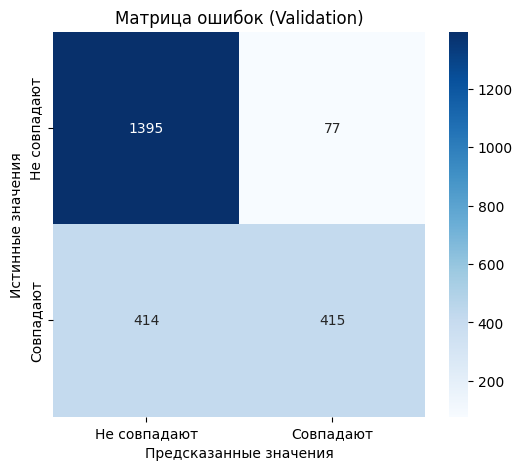

In [534]:
# Строим матрицу ошибок
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не совпадают', 'Совпадают'],
            yticklabels=['Не совпадают', 'Совпадают'])
plt.title('Матрица ошибок (Validation)')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()


In [535]:
# Коэффициенты модели (важность признаков)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nВАЖНОСТЬ ПРИЗНАКОВ (ПО КОЭФФИЦИЕНТАМ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ):")
print(feature_importance)


ВАЖНОСТЬ ПРИЗНАКОВ (ПО КОЭФФИЦИЕНТАМ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ):
                          feature  coefficient  abs_coefficient
0                      similarity    11.546694        11.546694
4              email_domain_match     0.173382         0.173382
3                   country_match     0.101866         0.101866
1          registration_diff_days    -0.075526         0.075526
2  registration_diff_standardized    -0.003020         0.003020


Наиболее важный признак similarity, показывающий совпадение пар дубликатов имен через нормализованное расстояние Левинштейна.

In [536]:
# Находим оптимальный порог по F1‑score
thresholds = np.linspace(0.1, 0.9, 90)
f1_scores = []

for threshold in thresholds:
    y_pred_temp = (y_val_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_temp))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Оптимальный порог классификации: {best_threshold:.3f}")
print(f"Максимальный F1-score: {max(f1_scores):.3f}")

# Применяем оптимальный порог
y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)
print(f"F1 с оптимальным порогом: {f1_score(y_val, y_val_pred_opt):.3f}")


Оптимальный порог классификации: 0.100
Максимальный F1-score: 0.809
F1 с оптимальным порогом: 0.809


In [537]:
# Находим оптимальный порог по F1‑score
thresholds = np.linspace(0.1, 0.9, 90)
f1_scores = []
precision_scores = []
recall_scores = []

for threshold in thresholds:
    y_pred_temp = (y_val_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_temp, zero_division=0))
    precision_scores.append(precision_score(y_val, y_pred_temp, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_temp, zero_division=0))
# Определяем оптимальный порог (где F1 максимальный)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

# Получаем значения метрик при оптимальном пороге
best_f1 = f1_scores[best_threshold_idx]
best_precision = precision_scores[best_threshold_idx]
best_recall = recall_scores[best_threshold_idx]

print("=" * 60)
print("ОПТИМИЗАЦИЯ ПОРОГА КЛАССИФИКАЦИИ")
print("=" * 60)

print(f"Оптимальный порог классификации: {best_threshold:.3f}")
print(f"Максимальный F1-score: {best_f1:.3f}")
print(f"Precision при оптимальном пороге: {best_precision:.3f}")
print(f"Recall при оптимальном пороге: {best_recall:.3f}")

# Применяем оптимальный порог для финальных предсказаний
y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)

ОПТИМИЗАЦИЯ ПОРОГА КЛАССИФИКАЦИИ
Оптимальный порог классификации: 0.100
Максимальный F1-score: 0.809
Precision при оптимальном пороге: 0.744
Recall при оптимальном пороге: 0.887


Низкий порог 0.100 даёт высокий Recall (мало пропусков), но умеренную Precision (есть ложные срабатывания).

Это подходит для задач, где пропуск истинного совпадения критичнее, чем ложное срабатывание (например, выявление дубликатов в базе данных).